In [1]:
"""
Entanglement Swapping and Bell State Measurement Demo using Qiskit

This script demonstrates:
1. What a Bell State Measurement (BSM) is
2. How entanglement swapping works
3. Verification that particles 1 and 4 become entangled after the swap
"""

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


In [2]:
def create_bell_pair(qc, q1, q2):
    """Create a Bell state (Φ⁺) between two qubits."""
    qc.h(q1)
    qc.cx(q1, q2)


def bell_state_measurement(qc, q1, q2, c1, c2):
    """
    Perform a Bell State Measurement on two qubits.
    
    This transforms the Bell basis to the computational basis:
    - |Φ⁺⟩ → |00⟩
    - |Φ⁻⟩ → |10⟩
    - |Ψ⁺⟩ → |01⟩
    - |Ψ⁻⟩ → |11⟩
    
    The circuit is essentially the reverse of Bell state creation:
    1. CNOT gate
    2. Hadamard gate
    3. Measurement
    """
    qc.cx(q1, q2)
    qc.h(q1)
    qc.measure(q1, c1)
    qc.measure(q2, c2)



In [3]:

# =============================================================================
# PART 1: Understanding Bell State Measurement
# =============================================================================

print("=" * 60)
print("PART 1: Bell State Measurement Basics")
print("=" * 60)

# Create a simple circuit to demonstrate BSM
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(2, 'c')
bsm_demo = QuantumCircuit(qr, cr)

# First create a Bell state
create_bell_pair(bsm_demo, qr[0], qr[1])
bsm_demo.barrier()

# Then perform BSM
bell_state_measurement(bsm_demo, qr[0], qr[1], cr[0], cr[1])

print("\nBell State Measurement Circuit:")
print(bsm_demo.draw(output='text'))

# Run simulation
simulator = AerSimulator()
job = simulator.run(bsm_demo, shots=1024)
result = job.result()
counts = result.get_counts()

print("\nResults of BSM on |Φ⁺⟩ state:")
print(f"Measurement outcomes: {counts}")
print("(Should be 100% '00' since we started with |Φ⁺⟩)")



PART 1: Bell State Measurement Basics

Bell State Measurement Circuit:
     ┌───┐      ░      ┌───┐┌─┐
q_0: ┤ H ├──■───░───■──┤ H ├┤M├
     └───┘┌─┴─┐ ░ ┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─░─┤ X ├─┤M├──╫─
          └───┘ ░ └───┘ └╥┘  ║ 
c: 2/════════════════════╩═══╩═
                         1   0 

Results of BSM on |Φ⁺⟩ state:
Measurement outcomes: {'00': 1024}
(Should be 100% '00' since we started with |Φ⁺⟩)


In [7]:

# =============================================================================
# PART 2: Full Entanglement Swapping Protocol
# =============================================================================

print("\n" + "=" * 60)
print("PART 2: Entanglement Swapping Protocol")
print("=" * 60)

# Create 4 qubits for the full protocol
# q0 (Alice) - q1 (Bob's first) | q2 (Bob's second) - q3 (Charlie)
qr = QuantumRegister(4, 'q')
cr_bsm = ClassicalRegister(2, 'bsm')  # Bob's BSM results
cr_verify = ClassicalRegister(2, 'verify')  # Verification measurements

swap_circuit = QuantumCircuit(qr, cr_bsm, cr_verify)

# Step 1: Create entangled pair between Alice (q0) and Bob (q1)
swap_circuit.h(qr[0])
swap_circuit.cx(qr[0], qr[1])

# Step 2: Create entangled pair between Bob (q2) and Charlie (q3)
swap_circuit.h(qr[2])
swap_circuit.cx(qr[2], qr[3])

swap_circuit.barrier(label='Initial Bell pairs')

# Step 3: Bob performs Bell State Measurement on q1 and q2
swap_circuit.cx(qr[1], qr[2])
swap_circuit.h(qr[1])
swap_circuit.measure(qr[1], cr_bsm[0])
swap_circuit.measure(qr[2], cr_bsm[1])

swap_circuit.barrier(label='BSM complete')

# Step 4: Apply corrections based on BSM outcome (for teleportation fidelity)
# These corrections ensure q0 and q3 end up in the same Bell state
# Note: Using if_test context manager (Qiskit 1.0+ syntax)
with swap_circuit.if_test((cr_bsm[1], 1)):
    swap_circuit.x(qr[3])
with swap_circuit.if_test((cr_bsm[0], 1)):
    swap_circuit.z(qr[3])

swap_circuit.barrier(label='Corrections')

# Step 5: Verify entanglement between Alice (q0) and Charlie (q3)
# by measuring in Bell basis
swap_circuit.cx(qr[0], qr[3])
swap_circuit.h(qr[0])
swap_circuit.measure(qr[0], cr_verify[0])
swap_circuit.measure(qr[3], cr_verify[1])

print("\nFull Entanglement Swapping Circuit:")
# print(swap_circuit.draw(output='text', fold=120))
print(swap_circuit.draw(output='text', fold=-1))

# Run simulation
job = simulator.run(swap_circuit, shots=4096)
result = job.result()
counts = result.get_counts()

print("\nResults (format: 'verify_bits bsm_bits'):")
for outcome, count in sorted(counts.items()):
    verify, bsm = outcome.split()
    print(f"  BSM={bsm}, Verification={verify}: {count} ({100*count/4096:.1f}%)")

print("\nInterpretation:")
print("- The verification bits should always be '00'")
print("- This confirms q0 and q3 are in the |Φ⁺⟩ Bell state")
print("- The BSM outcomes (00, 01, 10, 11) occur with ~25% probability each")


PART 2: Entanglement Swapping Protocol

Full Entanglement Swapping Circuit:
          ┌───┐      Initial Bell pairs               BSM complete                                                          Corrections      ┌───┐┌─┐
     q_0: ┤ H ├──■───────────░─────────────────────────────░─────────────────────────────────────────────────────────────────────░────────■──┤ H ├┤M├
          └───┘┌─┴─┐         ░               ┌───┐┌─┐      ░                                                                     ░        │  └───┘└╥┘
     q_1: ─────┤ X ├─────────░────────────■──┤ H ├┤M├──────░─────────────────────────────────────────────────────────────────────░────────┼────────╫─
          ┌───┐└───┘         ░          ┌─┴─┐└┬─┬┘└╥┘      ░                                                                     ░        │        ║ 
     q_2: ┤ H ├──■───────────░──────────┤ X ├─┤M├──╫───────░─────────────────────────────────────────────────────────────────────░────────┼────────╫─
          └───┘┌─┴─┐   

In [5]:

# =============================================================================
# PART 3: Detailed Analysis - Correlation Check
# =============================================================================

print("\n" + "=" * 60)
print("PART 3: Verifying Correlations in Different Bases")
print("=" * 60)

def verify_entanglement(basis='Z'):
    """
    Verify that q0 and q3 are entangled by checking correlations.
    
    For a Bell state |Φ⁺⟩:
    - Z-basis: perfect correlation (00 or 11)
    - X-basis: perfect correlation (++ or --)
    """
    qr = QuantumRegister(4, 'q')
    cr_bsm = ClassicalRegister(2, 'bsm')
    cr_alice = ClassicalRegister(1, 'alice')
    cr_charlie = ClassicalRegister(1, 'charlie')
    
    qc = QuantumCircuit(qr, cr_bsm, cr_alice, cr_charlie)
    
    # Create initial Bell pairs
    qc.h(qr[0])
    qc.cx(qr[0], qr[1])
    qc.h(qr[2])
    qc.cx(qr[2], qr[3])
    qc.barrier()
    
    # Bob's BSM
    qc.cx(qr[1], qr[2])
    qc.h(qr[1])
    qc.measure(qr[1], cr_bsm[0])
    qc.measure(qr[2], cr_bsm[1])
    qc.barrier()
    
    # Corrections (using if_test context manager for Qiskit 1.0+)
    with qc.if_test((cr_bsm[1], 1)):
        qc.x(qr[3])
    with qc.if_test((cr_bsm[0], 1)):
        qc.z(qr[3])
    qc.barrier()
    
    # Measure in specified basis
    if basis == 'X':
        qc.h(qr[0])
        qc.h(qr[3])
    
    qc.measure(qr[0], cr_alice[0])
    qc.measure(qr[3], cr_charlie[0])
    
    return qc


# Test Z-basis correlations
z_circuit = verify_entanglement('Z')
job = simulator.run(z_circuit, shots=4096)
counts = job.result().get_counts()

print("\nZ-basis measurements (Alice vs Charlie):")
correlations = {'same': 0, 'different': 0}
for outcome, count in counts.items():
    parts = outcome.split()
    alice = parts[0]
    charlie = parts[1]
    if alice == charlie:
        correlations['same'] += count
    else:
        correlations['different'] += count

print(f"  Same outcome: {correlations['same']} ({100*correlations['same']/4096:.1f}%)")
print(f"  Different outcome: {correlations['different']} ({100*correlations['different']/4096:.1f}%)")

# Test X-basis correlations
x_circuit = verify_entanglement('X')
job = simulator.run(x_circuit, shots=4096)
counts = job.result().get_counts()

print("\nX-basis measurements (Alice vs Charlie):")
correlations = {'same': 0, 'different': 0}
for outcome, count in counts.items():
    parts = outcome.split()
    alice = parts[0]
    charlie = parts[1]
    if alice == charlie:
        correlations['same'] += count
    else:
        correlations['different'] += count

print(f"  Same outcome: {correlations['same']} ({100*correlations['same']/4096:.1f}%)")
print(f"  Different outcome: {correlations['different']} ({100*correlations['different']/4096:.1f}%)")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
The results show perfect correlations in both Z and X bases,
confirming that q0 (Alice) and q3 (Charlie) are maximally entangled
after the entanglement swapping protocol - even though they never
directly interacted!

This is the magic of entanglement swapping: Bob's Bell State Measurement
on his two qubits (q1 and q2) projects Alice's and Charlie's qubits
into an entangled state.
""")


PART 3: Verifying Correlations in Different Bases

Z-basis measurements (Alice vs Charlie):
  Same outcome: 4096 (100.0%)
  Different outcome: 0 (0.0%)

X-basis measurements (Alice vs Charlie):
  Same outcome: 4096 (100.0%)
  Different outcome: 0 (0.0%)

CONCLUSION

The results show perfect correlations in both Z and X bases,
confirming that q0 (Alice) and q3 (Charlie) are maximally entangled
after the entanglement swapping protocol - even though they never
directly interacted!

This is the magic of entanglement swapping: Bob's Bell State Measurement
on his two qubits (q1 and q2) projects Alice's and Charlie's qubits
into an entangled state.



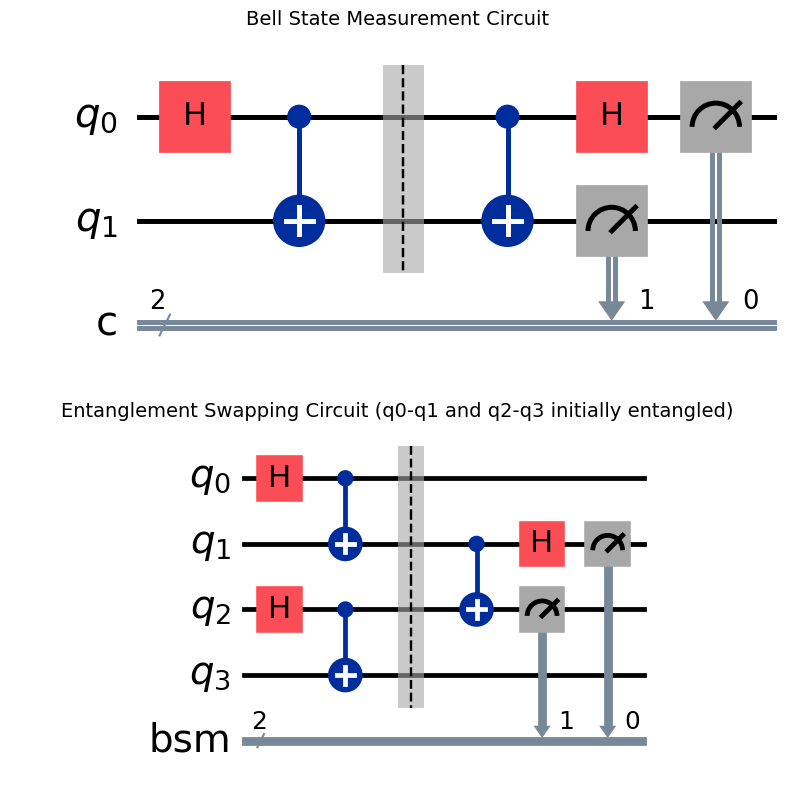

In [6]:

# =============================================================================
# PART 4: Save circuit diagrams
# =============================================================================

# Create a clean version of the BSM circuit for visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Simple BSM circuit
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(2, 'c')
bsm_simple = QuantumCircuit(qr, cr)
create_bell_pair(bsm_simple, qr[0], qr[1])
bsm_simple.barrier()
bell_state_measurement(bsm_simple, qr[0], qr[1], cr[0], cr[1])

bsm_simple.draw(output='mpl', ax=axes[0])
axes[0].set_title('Bell State Measurement Circuit', fontsize=14)

# Full swap circuit (simplified for visualization)
qr = QuantumRegister(4, 'q')
cr = ClassicalRegister(2, 'bsm')
swap_viz = QuantumCircuit(qr, cr)

# Bell pairs
swap_viz.h(qr[0])
swap_viz.cx(qr[0], qr[1])
swap_viz.h(qr[2])
swap_viz.cx(qr[2], qr[3])
swap_viz.barrier()

# BSM
swap_viz.cx(qr[1], qr[2])
swap_viz.h(qr[1])
swap_viz.measure(qr[1], cr[0])
swap_viz.measure(qr[2], cr[1])

swap_viz.draw(output='mpl', ax=axes[1])
axes[1].set_title('Entanglement Swapping Circuit (q0-q1 and q2-q3 initially entangled)', fontsize=14)


plt.tight_layout()
plt.show()

# plt.savefig('/home/claude/entanglement_circuits.png', dpi=150, bbox_inches='tight')
# print("\nCircuit diagrams saved to 'entanglement_circuits.png'")